In [1]:
import tensorflow as tf
from keras import layers
# from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
import numpy as np
import cv2
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import Callback, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from tensorflow.keras.callbacks import Callback , ReduceLROnPlateau , ModelCheckpoint, CSVLogger
from sklearn.metrics import cohen_kappa_score, accuracy_score
from tensorflow.keras.losses import categorical_crossentropy as logloss
from tensorflow.keras.metrics import categorical_accuracy
import pandas as pd 
import os
from PIL import Image
import scipy
from sklearn import metrics
from sklearn.model_selection import train_test_split
import json

2024-04-05 16:39:04.351481: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-05 16:39:04.351575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-05 16:39:04.482968: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_dir = '/kaggle/input/deepfake-and-real-images/Dataset/Train'
valid_dir = '/kaggle/input/deepfake-and-real-images/Dataset/Validation'
test_dir = '/kaggle/input/deepfake-and-real-images/Dataset/Test'

In [3]:
# View an image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

def view_random_image(target_dir, target_class):
  target_folder = target_dir + "/" + target_class
  print(f"target folder {target_folder}")
  random_image = random.sample(os.listdir(target_folder), 1)
  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off");

  print(f"Image shape: {img.shape}") # show the shape of the image

  return img

# View random image
# img = view_random_image(target_dir=train_dir,
#                         target_class="Real")

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.random.set_seed(42)

train_datagen = ImageDataGenerator(rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(valid_dir,
                                               batch_size=32,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               seed=42)

test_data = test_datagen.flow_from_directory(test_dir,
                                               batch_size=1,
                                               target_size=(224, 224),
                                               class_mode="binary",
                                               shuffle=False,
                                               seed=42)

Found 140002 images belonging to 2 classes.
Found 39428 images belonging to 2 classes.
Found 10905 images belonging to 2 classes.


In [5]:
# End to End TinyVGG Model

tf.random.set_seed(42)


#Create a CNN model (same as Tiny VGG - https://poloclub.github.io/cnn-explainer/)
model_1 = tf.keras.models.Sequential([
  tf.keras.layers.Conv2D(filters=20, 
                         kernel_size=3, # can also be (3, 3)
                         activation="relu", 
                         input_shape=(224, 224, 3)), # first layer specifies input shape (height, width, colour channels)
  tf.keras.layers.Conv2D(20, 3, activation="relu"),
  tf.keras.layers.MaxPool2D(pool_size=2, # pool_size can also be (2, 2)
                            padding="valid"), # padding can also be 'same'
  tf.keras.layers.Conv2D(20, 3, activation="relu"),
  tf.keras.layers.Conv2D(20, 3, activation="relu"), # activation='relu' == tf.keras.layers.Activations(tf.nn.relu)
  tf.keras.layers.MaxPool2D(4),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation="sigmoid") # binary activation output
])

# Compile the model
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# Fit the model
history_1 = model_1.fit(train_data,
                        epochs=5, #5, 8
                        steps_per_epoch=128, # 44, 99, 128, 4k XD
                        validation_data=valid_data,
                        validation_steps=128)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/5


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


  1/128 ━━━━━━━━━━━━━━━━━━━━ 37:33 18s/step - accuracy: 0.4688 - loss: 0.6945

I0000 00:00:1712335465.851819      96 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


128/128 ━━━━━━━━━━━━━━━━━━━━ 121s 810ms/step - accuracy: 0.5282 - loss: 0.6939 - val_accuracy: 0.6038 - val_loss: 0.6789
Epoch 2/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 96s 757ms/step - accuracy: 0.5896 - loss: 0.6705 - val_accuracy: 0.5928 - val_loss: 0.6613
Epoch 3/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 95s 750ms/step - accuracy: 0.5904 - loss: 0.6640 - val_accuracy: 0.5916 - val_loss: 0.6642
Epoch 4/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 89s 700ms/step - accuracy: 0.6033 - loss: 0.6617 - val_accuracy: 0.6106 - val_loss: 0.6565
Epoch 5/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 80s 629ms/step - accuracy: 0.6160 - loss: 0.6598 - val_accuracy: 0.6409 - val_loss: 0.6318


# Save the model
model_1.save("VGG_1.h5")

In [6]:
def load_and_prep_image(filename, img_shape=224):
  # Read in target file (an image)
  print(filename)
  img = tf.io.read_file(filename)

  img = tf.image.decode_image(img, channels=3)
  img = tf.image.resize(img, size = [img_shape, img_shape])
  img = img/255.
  return img

# print(test_data[0])

# # print(test_data)


# pred = model_1.predict(test_data[9000])
# ctr = 1 if pred > .50 else 0 
# print()
# pred

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 94s 9ms/step
[[4360 1132]
 [2913 2500]]


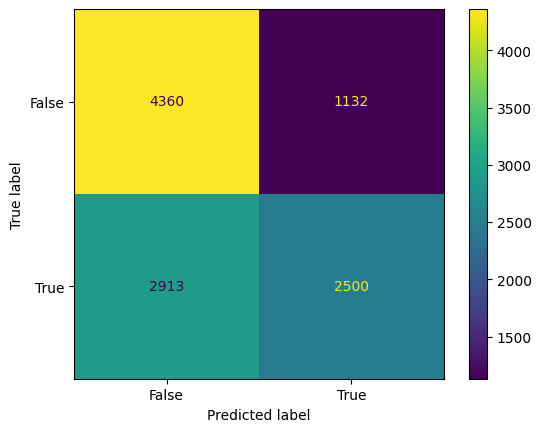

ROC AUC Score: 0.7049032339533822
AP Score: 0.6760710854854106

              precision    recall  f1-score   support

           0       0.60      0.79      0.68      5492
           1       0.69      0.46      0.55      5413

    accuracy                           0.63     10905
   macro avg       0.64      0.63      0.62     10905
weighted avg       0.64      0.63      0.62     10905

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7314 - loss: 0.5672
Final Test Acccuracy = 62.907


In [7]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix




# func to generate different score and confusion matrix from test score.
def gen_test_data(model):
    # Generate Confusion Matrix
    y_pred = model.predict(test_data)
    y_test = test_data.classes
    
#     y_pred_labels = np.argmax(y_pred, axis=1)
    y_pred_labels = (y_pred > 0.5).astype(np.float32)

    confusion_mat = confusion_matrix(y_test, y_pred_labels)
    print(confusion_mat)
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_mat, display_labels = [False, True])

    cm_display.plot()
    plt.show()
    
    # Get AUC, ROC and Precision Score
    print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_pred))
    print("AP Score:", metrics.average_precision_score(y_test, y_pred))
    print()
    print(metrics.classification_report(y_test, y_pred_labels))
    _, accu = model.evaluate(test_data)
    print('Final Test Acccuracy = {:.3f}'.format(accu*100))
    
gen_test_data(model_1)

In [8]:
#Save the model
# model_1.save("VGG_1.h5")

# def load_and_prep_image(filename, img_shape=224):
#   # Read in target file (an image)
#   print(filename)
#   img = tf.io.read_file(filename)

#   img = tf.image.decode_image(img, channels=3)
#   img = tf.image.resize(img, size = [img_shape, img_shape])
#   img = img/255.
#   return img

# test_img = load_and_prep_image(f"{test_dir}/Real/real_4.jpg")
# test_img = tf.expand_dims(test_img, axis=0)

import keras
model_1.save("/kaggle/working/VGG_01_FINAL.keras")

# reconstructed_model = keras.models.load_model("/kaggle/working/vgg_01.keras")

# # Let's check:
# print(np.testing.assert_allclose(
#     model_1.predict(test_img), reconstructed_model.predict(test_img)
# ))

In [9]:
# from keras.models import load_model
# vgg_1 = load_model('/kaggle/working/VGG_1.h5')


In [10]:
# def load_and_prep_image(filename, img_shape=224):
#   # Read in target file (an image)
#   print(filename)
#   img = tf.io.read_file(filename)

#   img = tf.image.decode_image(img, channels=3)
#   img = tf.image.resize(img, size = [img_shape, img_shape])
#   img = img/255.
#   return img

# test_img = load_and_prep_image(f"{test_dir}/Real/real_4.jpg")
# test_img = tf.expand_dims(test_img, axis=0)
# vgg_1.predict(test_img)

In [11]:
# import pandas as pd
# pd.DataFrame(history_1.history).plot(figsize=(10, 7));

In [12]:
# Plot the validation and training data separately
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  """ 
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
  plt.plot(epochs, loss, label='training_loss')
  plt.plot(epochs, val_loss, label='val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()

  # Plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

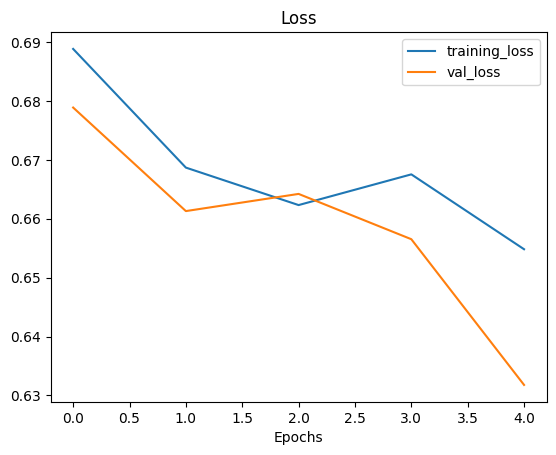

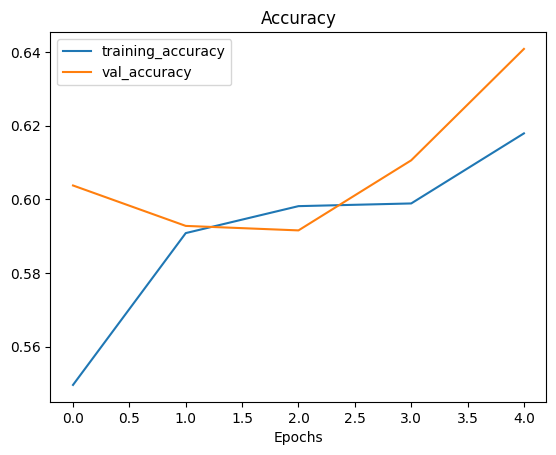

In [13]:
plot_loss_curves(history_1)

In [14]:
# model_2 with a MaxPool2D layer after every Conv2D layer

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

tf.random.set_seed(42)

model_2 = Sequential([
  Conv2D(20, 3, activation='relu', input_shape=(224, 224, 3)),
  MaxPool2D(pool_size=2), # reduce number of features by half
  Conv2D(20, 3, activation='relu'),
  MaxPool2D(),
  Conv2D(20, 3, activation='relu'),
  MaxPool2D(),
  Flatten(),
  Dense(1, activation='sigmoid')
])

model_2.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

history_2 = model_2.fit(train_data,
                        epochs=6,
                        steps_per_epoch=256,
                        validation_data=valid_data,
                        validation_steps=256)

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/6
256/256 ━━━━━━━━━━━━━━━━━━━━ 193s 723ms/step - accuracy: 0.5253 - loss: 0.6914 - val_accuracy: 0.5609 - val_loss: 0.6863
Epoch 2/6
256/256 ━━━━━━━━━━━━━━━━━━━━ 178s 698ms/step - accuracy: 0.6003 - loss: 0.6717 - val_accuracy: 0.6295 - val_loss: 0.6412
Epoch 3/6
256/256 ━━━━━━━━━━━━━━━━━━━━ 166s 650ms/step - accuracy: 0.6194 - loss: 0.6567 - val_accuracy: 0.6244 - val_loss: 0.6449
Epoch 4/6
256/256 ━━━━━━━━━━━━━━━━━━━━ 160s 629ms/step - accuracy: 0.6266 - loss: 0.6463 - val_accuracy: 0.6490 - val_loss: 0.6283
Epoch 5/6
256/256 ━━━━━━━━━━━━━━━━━━━━ 142s 558ms/step - accuracy: 0.6190 - loss: 0.6542 - val_accuracy: 0.6577 - val_loss: 0.6163
Epoch 6/6
  7/256 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.5856 - loss: 0.6453

/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


256/256 ━━━━━━━━━━━━━━━━━━━━ 136s 534ms/step - accuracy: 0.6372 - loss: 0.6331 - val_accuracy: 0.6133 - val_loss: 0.6469


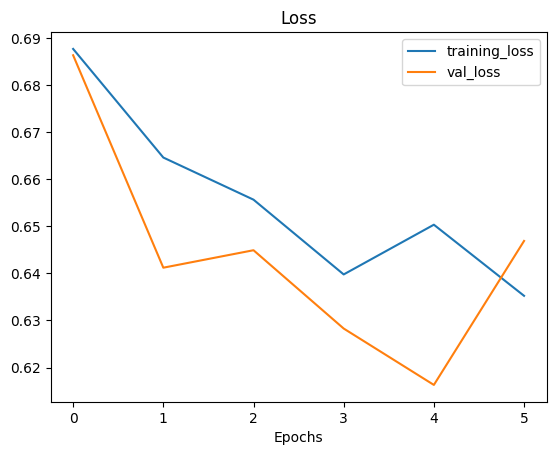

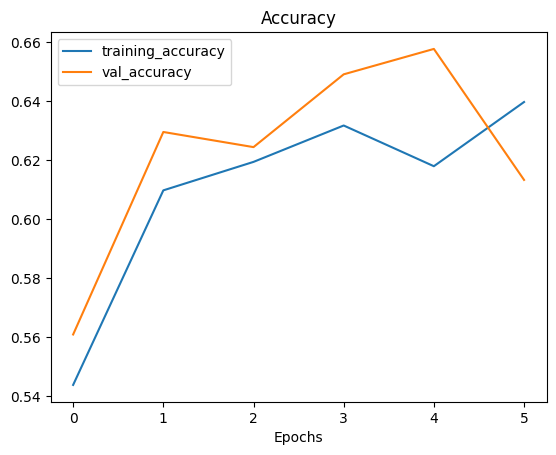

In [15]:
plot_loss_curves(history_2)

In [16]:
model_2.save("VGG_2_FINAL.h5")

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 36s 3ms/step
[[4742  750]
 [3720 1693]]


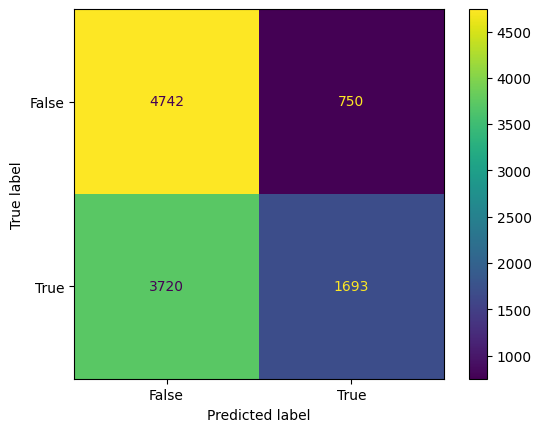

ROC AUC Score: 0.6939271558893113
AP Score: 0.6599331916375595

              precision    recall  f1-score   support

           0       0.56      0.86      0.68      5492
           1       0.69      0.31      0.43      5413

    accuracy                           0.59     10905
   macro avg       0.63      0.59      0.56     10905
weighted avg       0.63      0.59      0.56     10905

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.7696 - loss: 0.5216
Final Test Acccuracy = 59.010


In [17]:
# TODO: Try DataAugmentation during image preprocessing.
gen_test_data(model_2)

In [18]:
# def load_and_prep_image(filename, img_shape=224):
#   # Read in target file (an image)
#   print(filename)
#   img = tf.io.read_file(filename)

#   img = tf.image.decode_image(img, channels=3)
#   img = tf.image.resize(img, size = [img_shape, img_shape])
#   img = img/255.
#   return img

In [19]:
# train_img_path_1 = f"{test_dir}/Real/real_4.jpg"
# train_img_path_2 = f"{test_dir}/Fake/fake_12.jpg"
# train_img_real_1 = load_and_prep_image(train_img_path_1)
# train_img_real_2 = load_and_prep_image(train_img_path_2)
# train_img_real_1 = tf.expand_dims(train_img_real_1, axis=0)
# train_img_real_2 = tf.expand_dims(train_img_real_2, axis=0)

In [20]:
# pred_1 = model_2.predict(train_img_real_1)
# pred_2 = model_2.predict(train_img_real_2)
# print(pred_1)
# print(pred_2)

In [21]:
input_shape=(224,224,3)
batch_size=64


def build_model():
    res_densenet = ResNet50(
                        weights='imagenet',
                        include_top=False,
                        input_shape=input_shape
                        )
    res_model = Sequential([res_densenet,
                        layers.GlobalAveragePooling2D(),
                        layers.Dense(64,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dropout(0.5),
                        layers.Dense(1, activation='sigmoid')
                        ])
    res_model.compile(optimizer=Adam(),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                 )
    return res_model


model_resnet = build_model()
model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ ?                      │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [22]:
tf.random.set_seed(42)
history = model_resnet.fit(train_data,
    epochs = 8,
    steps_per_epoch = 256,
    validation_data =valid_data,
    validation_steps = 256
)

Epoch 1/8


W0000 00:00:1712337207.314767      94 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.6866 - loss: 0.6846

W0000 00:00:1712337339.103265      94 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


256/256 ━━━━━━━━━━━━━━━━━━━━ 241s 619ms/step - accuracy: 0.6867 - loss: 0.6844 - val_accuracy: 0.4994 - val_loss: 0.6944
Epoch 2/8
256/256 ━━━━━━━━━━━━━━━━━━━━ 148s 580ms/step - accuracy: 0.8152 - loss: 0.4008 - val_accuracy: 0.5009 - val_loss: 0.6935
Epoch 3/8
256/256 ━━━━━━━━━━━━━━━━━━━━ 144s 563ms/step - accuracy: 0.8738 - loss: 0.3026 - val_accuracy: 0.7391 - val_loss: 0.5450
Epoch 4/8
256/256 ━━━━━━━━━━━━━━━━━━━━ 140s 549ms/step - accuracy: 0.8984 - loss: 0.2523 - val_accuracy: 0.8899 - val_loss: 0.2650
Epoch 5/8
256/256 ━━━━━━━━━━━━━━━━━━━━ 136s 531ms/step - accuracy: 0.9109 - loss: 0.2145 - val_accuracy: 0.8827 - val_loss: 0.2529
Epoch 6/8


W0000 00:00:1712337933.362457      97 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


256/256 ━━━━━━━━━━━━━━━━━━━━ 128s 501ms/step - accuracy: 0.9274 - loss: 0.1964 - val_accuracy: 0.8707 - val_loss: 0.3139
Epoch 7/8
256/256 ━━━━━━━━━━━━━━━━━━━━ 123s 483ms/step - accuracy: 0.9258 - loss: 0.1876 - val_accuracy: 0.8223 - val_loss: 0.4197
Epoch 8/8
256/256 ━━━━━━━━━━━━━━━━━━━━ 124s 485ms/step - accuracy: 0.9267 - loss: 0.1996 - val_accuracy: 0.8850 - val_loss: 0.3145


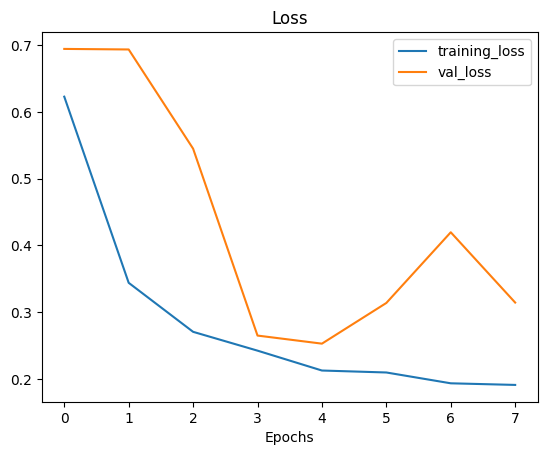

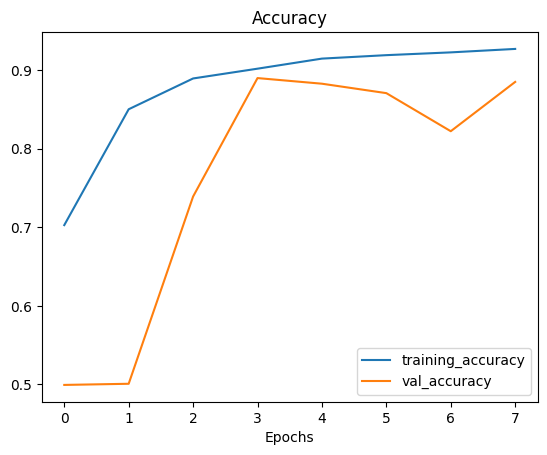

In [23]:
plot_loss_curves(history)

In [24]:
# ResNet50_1 Save
import keras
model_resnet.save("/kaggle/working/Res_01_FINAL.keras")

# reconstructed_model = keras.models.load_model("/kaggle/working/Res_01.keras")

# # Let's check:
# np.testing.assert_allclose(
#     model.predict(test_input), reconstructed_model.predict(test_input)
# )

# filename = 'ResNet50_1.pkl'
# pickle.dump(model_resnet, open(filename, 'wb'))

In [25]:
# def load_and_prep_image(filename, img_shape=224):
#   # Read in target file (an image)
#   print(filename)
#   img = tf.io.read_file(filename)

#   img = tf.image.decode_image(img, channels=3)
#   img = tf.image.resize(img, size = [img_shape, img_shape])
#   img = img/255.
#   return img

# test_img = load_and_prep_image(f"{test_dir}/Fake/fake_10.jpg")
# test_img = tf.expand_dims(test_img, axis=0)
# # vggyo.predict(test_img)
# model_resnet.predict(test_img)

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 78s 7ms/step
[[5147  345]
 [1926 3487]]


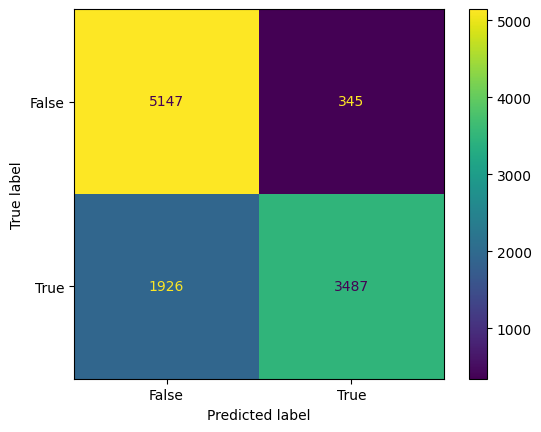

ROC AUC Score: 0.918391028503714
AP Score: 0.9124078307687831

              precision    recall  f1-score   support

           0       0.73      0.94      0.82      5492
           1       0.91      0.64      0.75      5413

    accuracy                           0.79     10905
   macro avg       0.82      0.79      0.79     10905
weighted avg       0.82      0.79      0.79     10905

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 100s 9ms/step - accuracy: 0.8990 - loss: 0.2520
Final Test Acccuracy = 79.175


In [26]:
# from keras.models import load_model
# vggyo = load_model('/kaggle/working/Res_0100.keras')

# def load_and_prep_image(filename, img_shape=224):
#   # Read in target file (an image)
#   print(filename)
#   img = tf.io.read_file(filename)

#   img = tf.image.decode_image(img, channels=3)
#   img = tf.image.resize(img, size = [img_shape, img_shape])
#   img = img/255.
#   return img

# test_img = load_and_prep_image(f"{test_dir}/Real/real_4.jpg")
# test_img = tf.expand_dims(test_img, axis=0)
# vggyo.predict(test_img)

gen_test_data(model_resnet)

In [27]:
def build_model_2():
    densenet = ResNet50(
                        weights='imagenet',
                        include_top=False,
                        input_shape=input_shape
                        )
    model = Sequential([densenet,
                        layers.GlobalAveragePooling2D(),
                        layers.Dense(512,activation='relu'),
                        layers.Dense(128,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dense(64,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dense(64,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dropout(0.5),
                        layers.Dense(128,activation='relu'),
                        layers.Flatten(),
                        layers.Dense(128,activation='relu'),
                        layers.Dense(1, activation='sigmoid')
                        ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                 )
    return model


model_resnet_2 = build_model_2()
model_resnet_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ ?                      │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [28]:
tf.random.set_seed(42)
history_resnet_2 = model_resnet_2.fit(train_data,
    epochs = 16,
    steps_per_epoch = 128,
    validation_data =valid_data,
    validation_steps = 126
)

Epoch 1/16


W0000 00:00:1712338572.648365      97 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.5886 - loss: 0.6638

W0000 00:00:1712338634.965165      95 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


128/128 ━━━━━━━━━━━━━━━━━━━━ 138s 568ms/step - accuracy: 0.5893 - loss: 0.6632 - val_accuracy: 0.5010 - val_loss: 0.7459
Epoch 2/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 67s 529ms/step - accuracy: 0.8808 - loss: 0.3157 - val_accuracy: 0.5032 - val_loss: 0.7248
Epoch 3/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 66s 514ms/step - accuracy: 0.9216 - loss: 0.2071 - val_accuracy: 0.4750 - val_loss: 0.7110
Epoch 4/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 64s 501ms/step - accuracy: 0.9267 - loss: 0.1991 - val_accuracy: 0.5141 - val_loss: 0.6988
Epoch 5/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 61s 476ms/step - accuracy: 0.9331 - loss: 0.1717 - val_accuracy: 0.6538 - val_loss: 0.6049
Epoch 6/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 466ms/step - accuracy: 0.9361 - loss: 0.1635 - val_accuracy: 0.6939 - val_loss: 0.6141
Epoch 7/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 59s 462ms/step - accuracy: 0.9330 - loss: 0.1639 - val_accuracy: 0.6009 - val_loss: 0.8969
Epoch 8/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 458ms/step - accuracy: 0.9323 - loss: 0.1795 - va

W0000 00:00:1712339198.119343      95 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 448ms/step - accuracy: 0.9488 - loss: 0.1293 - val_accuracy: 0.8212 - val_loss: 0.5518
Epoch 12/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 451ms/step - accuracy: 0.9452 - loss: 0.1387 - val_accuracy: 0.9395 - val_loss: 0.1492
Epoch 13/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 455ms/step - accuracy: 0.9601 - loss: 0.1143 - val_accuracy: 0.8762 - val_loss: 0.3971
Epoch 14/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 58s 455ms/step - accuracy: 0.9603 - loss: 0.1184 - val_accuracy: 0.9182 - val_loss: 0.2335
Epoch 15/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 56s 441ms/step - accuracy: 0.9613 - loss: 0.1147 - val_accuracy: 0.8772 - val_loss: 0.4327
Epoch 16/16
128/128 ━━━━━━━━━━━━━━━━━━━━ 57s 450ms/step - accuracy: 0.9679 - loss: 0.1096 - val_accuracy: 0.8991 - val_loss: 0.2490


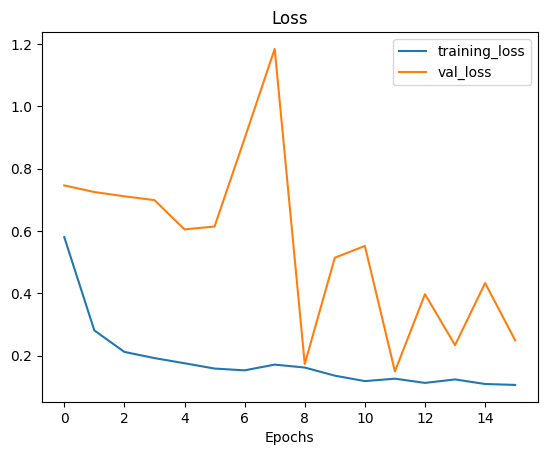

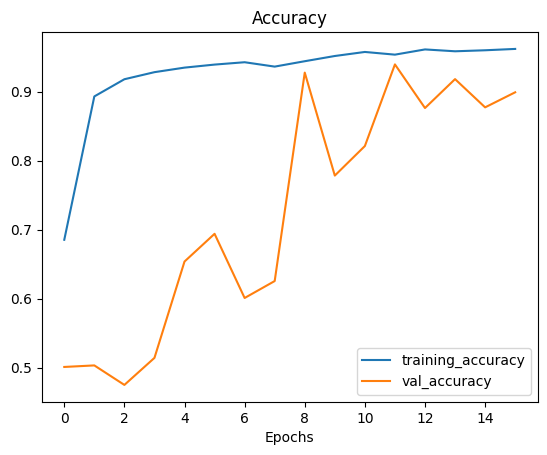

In [29]:
plot_loss_curves(history_resnet_2)

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 78s 7ms/step
[[5105  387]
 [1358 4055]]


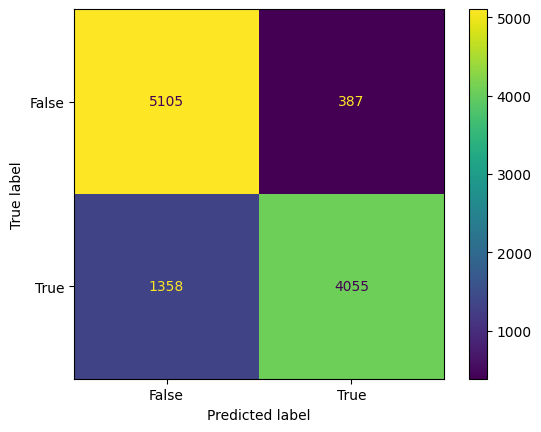

ROC AUC Score: 0.9346302749080367
AP Score: 0.9328765131730601

              precision    recall  f1-score   support

           0       0.79      0.93      0.85      5492
           1       0.91      0.75      0.82      5413

    accuracy                           0.84     10905
   macro avg       0.85      0.84      0.84     10905
weighted avg       0.85      0.84      0.84     10905

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 104s 9ms/step - accuracy: 0.9061 - loss: 0.2336
Final Test Acccuracy = 83.998


In [30]:
gen_test_data(model_resnet_2)

In [31]:
# ResNet50_1 Save
import keras
model_resnet_2.save("/kaggle/working/Res_02_FINAL.keras")

In [32]:
# ResNet50_2 Save

# model_resnet_2.save("ResNet50_2.h5")

# tf.random.set_seed(42)
# history_resnet_2 = model_resnet_2.fit(train_data,
#     epochs = 6,
#     steps_per_epoch = 1024,
#     validation_data =valid_data,
#     validation_steps = 1024
# )


In [33]:
# plot_loss_curves(history_resnet_2)

# InceptionNet

In [34]:
from keras.applications.inception_v3 import InceptionV3

input_shape=(224,224,3)
batch_size=64

def build_model_inception():
    densenet = InceptionV3(
                        weights='imagenet',
                        include_top=False,
                        input_shape=input_shape,
                        )
    model = Sequential([densenet,
                        layers.GlobalAveragePooling2D(),
                        layers.Dense(512,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dense(256,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dense(128,activation='relu'),
                        layers.BatchNormalization(),
                        layers.Dropout(0.5),
                        layers.Dense(1, activation='sigmoid')
                        ])
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy']
                 )
    return model

model_icv3 = build_model_inception()
model_icv3.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ ?                      │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ ?                      │   0 (unbuilt) │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_98          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_99          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_100         │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [35]:
tf.random.set_seed(42)
history_icv3 = model_icv3.fit(train_data,
    epochs = 8,
    steps_per_epoch = 1024,
    validation_data =valid_data,
    validation_steps = 1024
)

Epoch 1/8


W0000 00:00:1712339867.829085      96 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


 457/1024 ━━━━━━━━━━━━━━━━━━━━ 5:00 530ms/step - accuracy: 0.7357 - loss: 0.5909

W0000 00:00:1712340109.625132      97 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1024/1024 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.8021 - loss: 0.4589

W0000 00:00:1712340357.319019      94 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1024/1024 ━━━━━━━━━━━━━━━━━━━━ 676s 557ms/step - accuracy: 0.8022 - loss: 0.4587 - val_accuracy: 0.8692 - val_loss: 0.3264
Epoch 2/8
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 444s 434ms/step - accuracy: 0.9382 - loss: 0.1651 - val_accuracy: 0.9192 - val_loss: 0.2178
Epoch 3/8


W0000 00:00:1712340882.568857      96 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
/opt/conda/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


1024/1024 ━━━━━━━━━━━━━━━━━━━━ 501s 489ms/step - accuracy: 0.9547 - loss: 0.1190 - val_accuracy: 0.9463 - val_loss: 0.1398
Epoch 4/8
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 418s 408ms/step - accuracy: 0.9610 - loss: 0.1068 - val_accuracy: 0.9470 - val_loss: 0.1384
Epoch 5/8
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 160s 157ms/step - accuracy: 0.9676 - loss: 0.0883 - val_accuracy: 0.9460 - val_loss: 0.1594
Epoch 6/8
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 418s 406ms/step - accuracy: 0.9693 - loss: 0.0837 - val_accuracy: 0.8847 - val_loss: 0.3408
Epoch 7/8
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 454s 444ms/step - accuracy: 0.9725 - loss: 0.0778 - val_accuracy: 0.9406 - val_loss: 0.1890
Epoch 8/8
1024/1024 ━━━━━━━━━━━━━━━━━━━━ 408s 398ms/step - accuracy: 0.9736 - loss: 0.0751 - val_accuracy: 0.9647 - val_loss: 0.0917


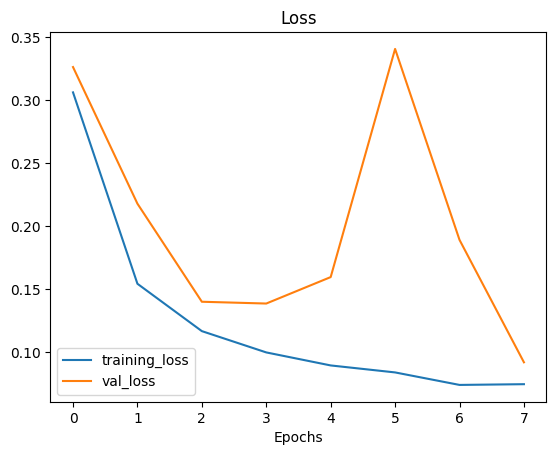

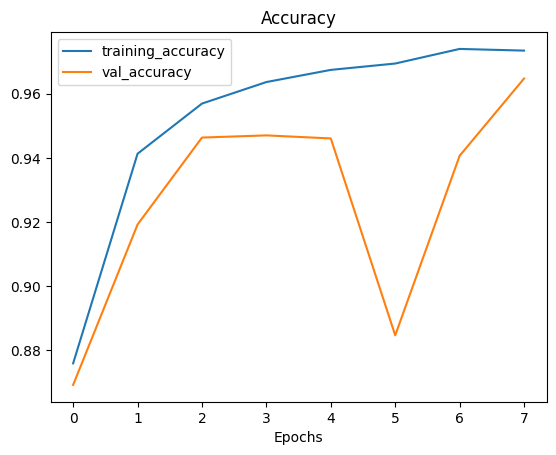

In [36]:
plot_loss_curves(history_icv3)

In [37]:
# InceptionNetV3_1 Save
# ResNet50_1 Save
import keras
model_icv3.save("/kaggle/working/ICV3_FINAL.keras")


# filename = 'InceptionNetV3_1.pkl'
# pickle.dump(model_icv3, open(filename, 'wb'))

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 90s 7ms/step
[[5007  485]
 [ 638 4775]]


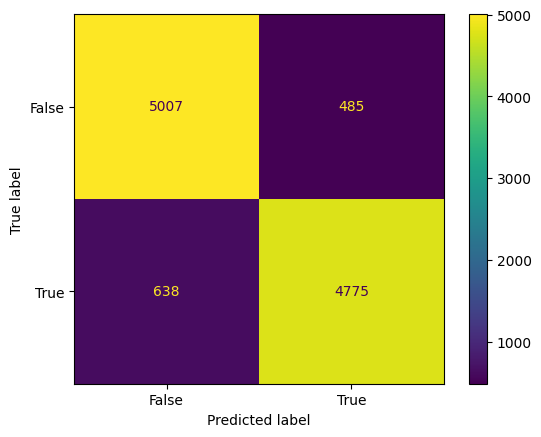

ROC AUC Score: 0.959029148623751
AP Score: 0.9641436203058062

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      5492
           1       0.91      0.88      0.89      5413

    accuracy                           0.90     10905
   macro avg       0.90      0.90      0.90     10905
weighted avg       0.90      0.90      0.90     10905

10905/10905 ━━━━━━━━━━━━━━━━━━━━ 113s 10ms/step - accuracy: 0.9145 - loss: 0.2264
Final Test Acccuracy = 89.702


In [38]:
# tf.random.set_seed(42)
# history_icv3_2 = model_icv3.fit(train_data,
#     epochs = 24,
#     steps_per_epoch = 1024,
#     validation_data =valid_data,
#     validation_steps = 1024
# )

gen_test_data(model_icv3)

In [39]:
# plot_loss_curves(history_icv3_2)